Diet x Weight Loss Project
Dr. Yuri Pritykin and Dr. Lydia Lynch
This file is designed for RNA Quality Control

In [87]:
# Download Packages
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import annoy

from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sc.set_figure_params(figsize=(5,5)) # no blurry figures allowed

In [88]:
# Load Multiome Data
dr = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/cr_arc_outputs/'

nk_sfd = sc.read_10x_h5(dr + 'NK_1-SFD/outs/filtered_feature_bc_matrix.h5', gex_only=False)
nk_hfd = sc.read_10x_h5(dr + 'NK_2-HFD/outs/filtered_feature_bc_matrix.h5', gex_only=False)
nk_glp = sc.read_10x_h5(dr + 'NK_3-HFD_GLP/outs/filtered_feature_bc_matrix.h5', gex_only=False)
nk_cr  = sc.read_10x_h5(dr + 'NK_4-HFD_CR/outs/filtered_feature_bc_matrix.h5', gex_only=False)

In [89]:
# Investigating Structure of Data
for name, adata in [('NK_SFD', nk_sfd), ('NK_HFD', nk_hfd), ('NK_GLP', nk_glp), ('NK_CR', nk_cr)]:
    print(f"\n--- {name} ---")
    print(adata)
    print(Counter(adata.var['feature_types']))
    print(adata.var.iloc[:3, :5].to_string())
    print("\nExpression matrix (5 cells x 5 genes):")
    gex = adata[:, adata.var['feature_types'] == 'Gene Expression'].copy()
    gex.var_names_make_unique()
    print(pd.DataFrame(
        gex.X[:5, :5].toarray(),
        index=gex.obs_names[:5],
        columns=gex.var_names[:5]
    ).to_string())


--- NK_SFD ---
AnnData object with n_obs × n_vars = 4641 × 113467
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
Counter({'Peaks': 81182, 'Gene Expression': 32285})
                   gene_ids    feature_types genome              interval
Xkr4     ENSMUSG00000051951  Gene Expression   mm10  chr1:3671497-3671498
Gm1992   ENSMUSG00000089699  Gene Expression   mm10  chr1:3466586-3466587
Gm19938  ENSMUSG00000102331  Gene Expression   mm10  chr1:3658903-3658904

Expression matrix (5 cells x 5 genes):
                    Xkr4  Gm1992  Gm19938  Gm37381  Rp1
AAACAGCCACCTAAGC-1   0.0     0.0      0.0      0.0  0.0
AAACAGCCAGATTCAT-1   0.0     0.0      0.0      0.0  0.0
AAACAGCCATGAATCT-1   0.0     0.0      0.0      0.0  0.0
AAACATGCAAGGCCAA-1   0.0     0.0      0.0      0.0  0.0
AAACATGCACAACAAA-1   0.0     0.0      0.0      0.0  0.0

--- NK_HFD ---
AnnData object with n_obs × n_vars = 5637 × 117997
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
Counter({'Peaks': 85712,

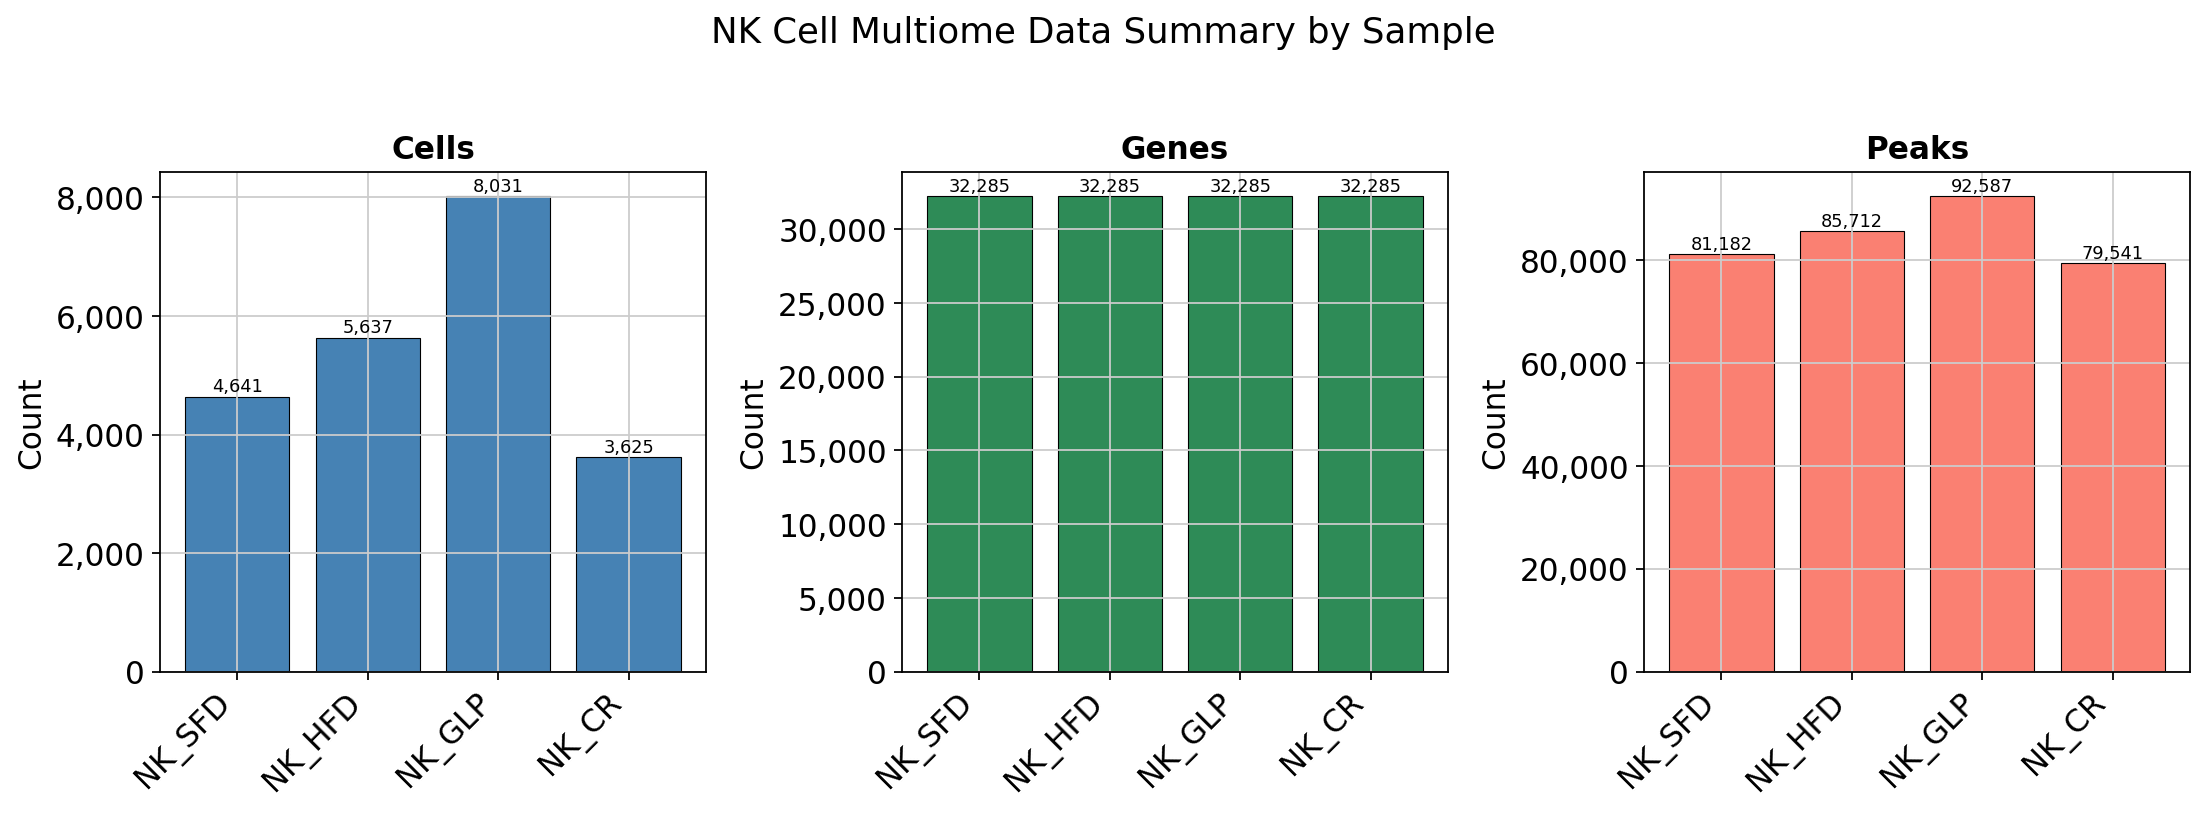

In [90]:
# Bar plot with # of cells
import matplotlib.pyplot as plt
import numpy as np

samples = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']
cells = [4641, 5637, 8031, 3625]
genes = [32285, 32285, 32285, 32285]
peaks = [81182, 85712, 92587, 79541]

x = np.arange(len(samples))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('Cells',  cells,  'steelblue'),
    ('Genes',  genes,  'seagreen'),
    ('Peaks',  peaks,  'salmon'),
]

for ax, (title, values, color) in zip(axes, metrics):
    ax.bar(samples, values, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(samples, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
    for i, v in enumerate(values):
        ax.text(i, v + max(values)*0.01, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('NK Cell Multiome Data Summary by Sample', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('sample_summary_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# Quality Control Functions

# Violin Plot Creation to Visualize Distributions
def qc(adata):
    adata.var['mt'] = adata.var_names.str.startswith('mt-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    
    ax = sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
                      multi_panel=True, stripplot=False, show=False)
    labels = ['Genes', 'UMI Counts', 'Mitochondrial Percent']
    for a, label in zip(ax.axes.flat, labels):
        a.set_title(label)
        a.set_xlabel(label)
    plt.show()
    
# n_genes by MT % to create thresholds for low genes and mt
def qc2(adata, low_n_genes_thres, high_mt_thres):
    adata.obs["low_n_genes"]  = adata.obs["n_genes_by_counts"] <= low_n_genes_thres # flag for filtering
    adata.obs["high_mt"]      = adata.obs["pct_counts_mt"]     >= high_mt_thres # flag for filtering
    
    ct_pl_col = sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="low_n_genes", show=False)
    ct_pl_col.set_xlim(0, max(adata.obs['total_counts']))
    ct_pl_col.set_ylim(0, max(adata.obs['n_genes_by_counts']))
    ct_pl_col.axhline(low_n_genes_thres,  c="r", linestyle='--')
    plt.show()
    
    mt_ct_pl = sc.pl.scatter(adata, x="pct_counts_mt", y="n_genes_by_counts", show=False)
    mt_ct_pl.axvline(high_mt_thres,       c="r", linestyle='--')
    mt_ct_pl.axhline(low_n_genes_thres,   c="r", linestyle='--')
    plt.show()

# filter out the cells determined by the above
def qc_filter_cells(adata):
    print("Prior")
    print(adata.shape)
    adata = adata[adata.obs["low_n_genes"] == False]
    print("Post Cells with Low n Gene Filtering")
    print(adata.shape)
    adata = adata[adata.obs["high_mt"] == False]
    print("Post Cells with High MT Fraction Gene Filtering")
    print(adata.shape)
    return adata

# determine potential doublets by cutting off at a good threshold
def qc3(adata, high_ct_thres):
    adata.obs["high_counts"] = adata.obs["total_counts"] >= high_ct_thres  # flag for filtering
    ct_pl_col = sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="total_counts", show=False)
    ct_pl_col.set_xlim(0, max(adata.obs['total_counts']))
    ct_pl_col.set_ylim(0, max(adata.obs['n_genes_by_counts']))
    ct_pl_col.axvline(high_ct_thres, c="r", linestyle='--')
    plt.show()
    cell_counts = np.sum(adata.X, axis=1)
    p = ggplot(pd.DataFrame({"cell count": np.array(cell_counts).flatten()}), aes(x="cell count")) + \
        geom_histogram() + \
        geom_vline(xintercept=high_ct_thres, color="blue")
    print(p)

# will remove cells if they have counts that are simply too high
def qc_filter_cells2(adata):
    print("prior")
    print(adata.shape)
    adata = adata[adata.obs["high_counts"] == False]
    print("after filtering out high counts")
    print(adata.shape)
    return adata

# will remove doublets
def remove_doublets(adata, doublet_score_thres=0.20):
    print("Prior")
    print(adata.shape)
    sc.pp.scrublet(adata, batch_key=None)
    adata = adata[adata.obs['doublet_score'] < doublet_score_thres]
    print(f"After doublet removal (threshold={doublet_score_thres})")
    print(adata.shape)
    return adata


=== NK_SFD ===


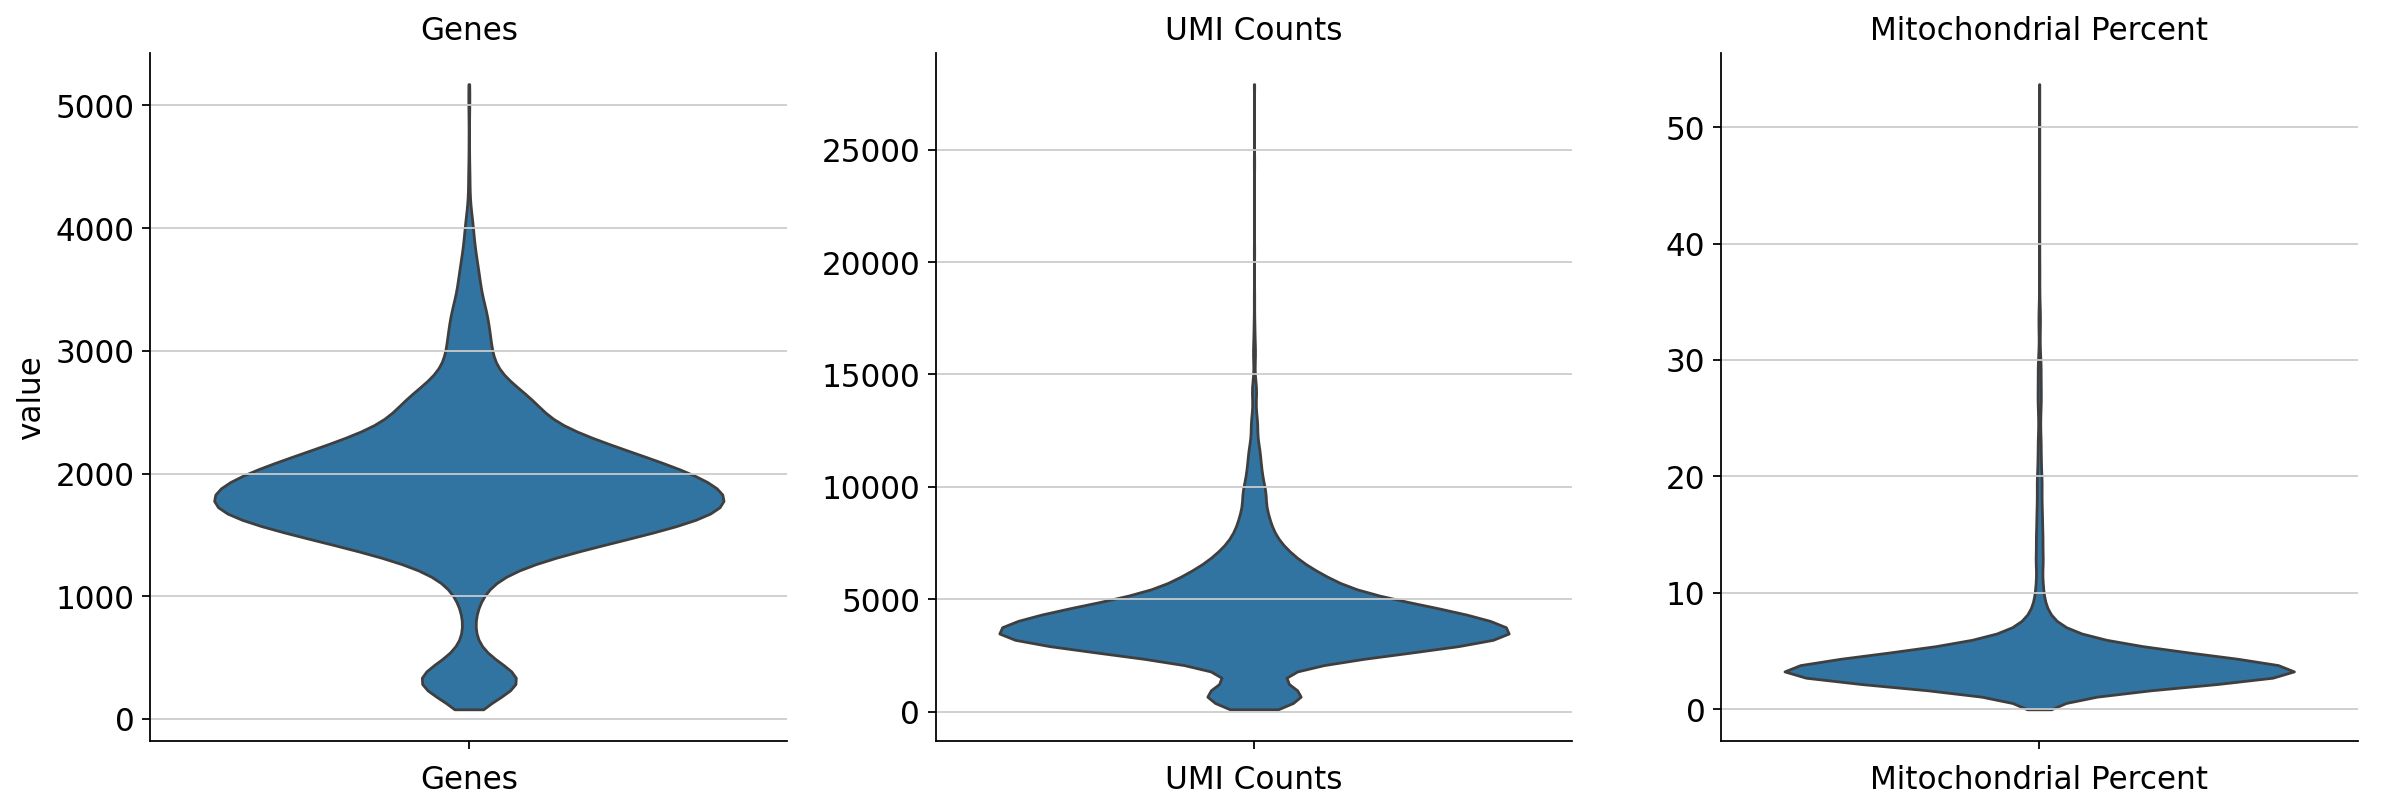


=== NK_HFD ===


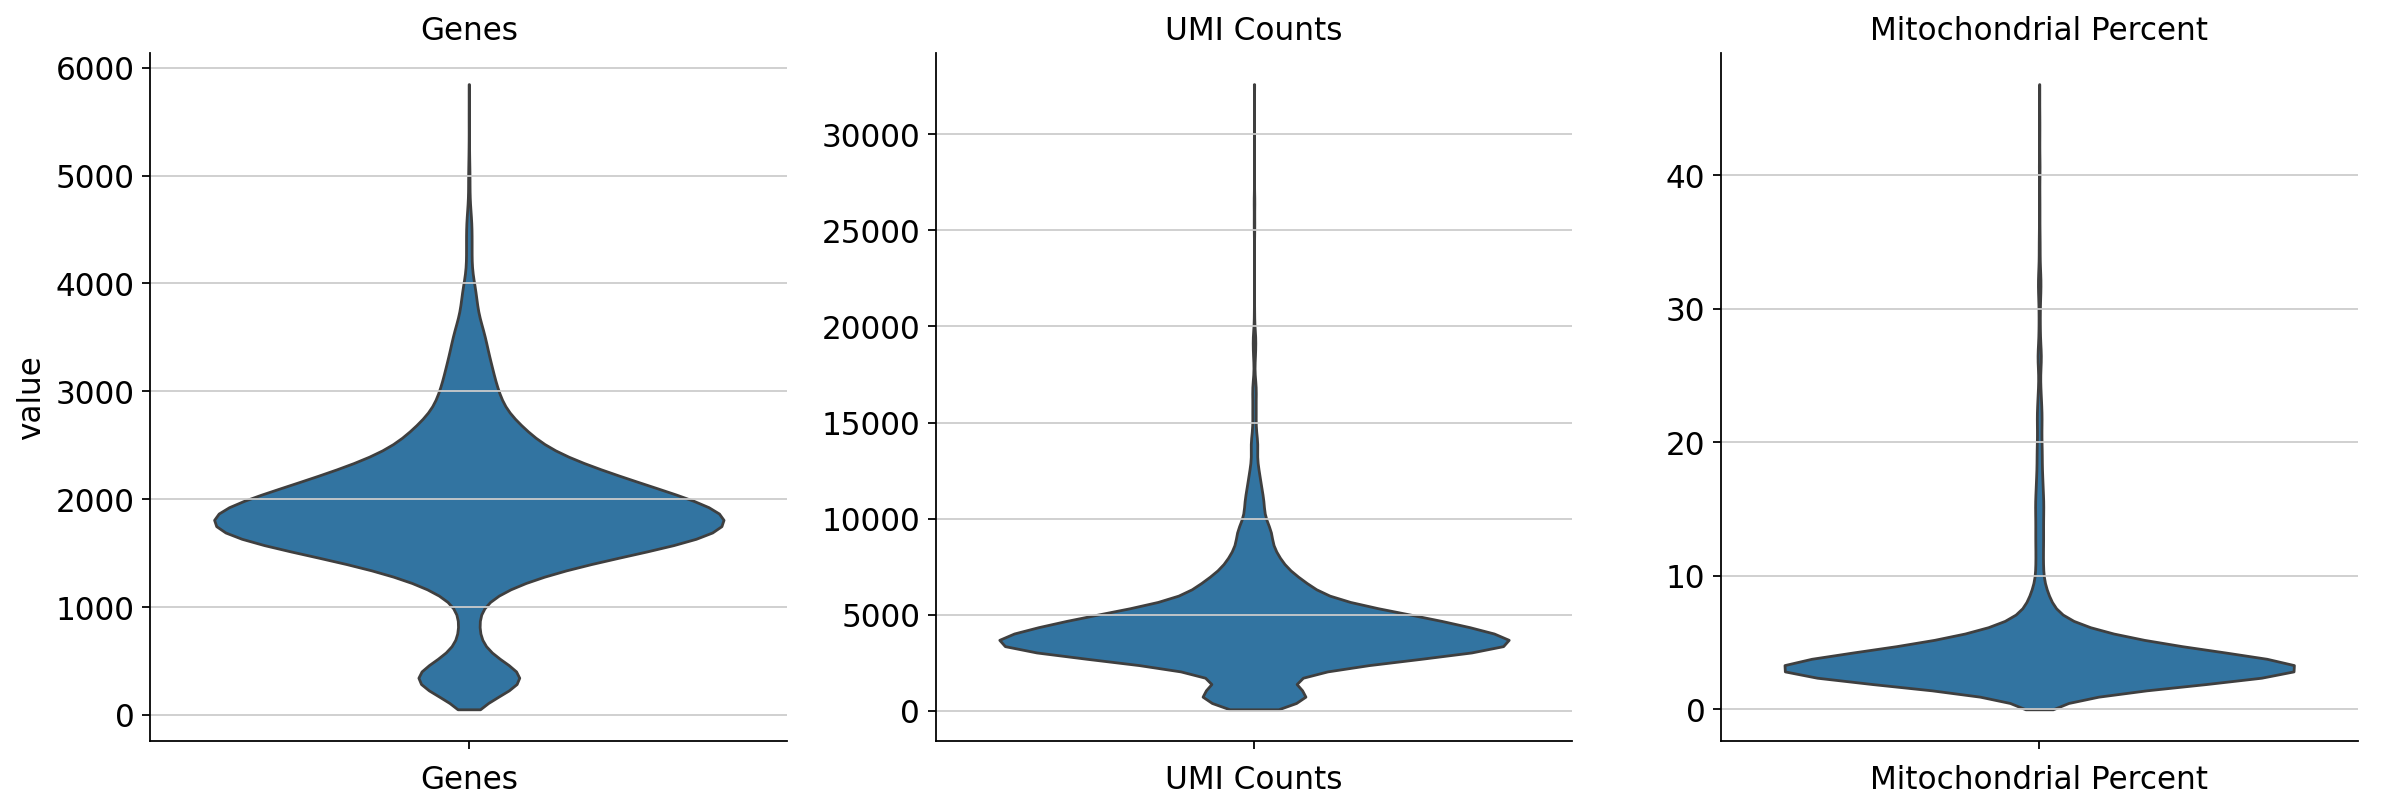


=== NK_GLP ===


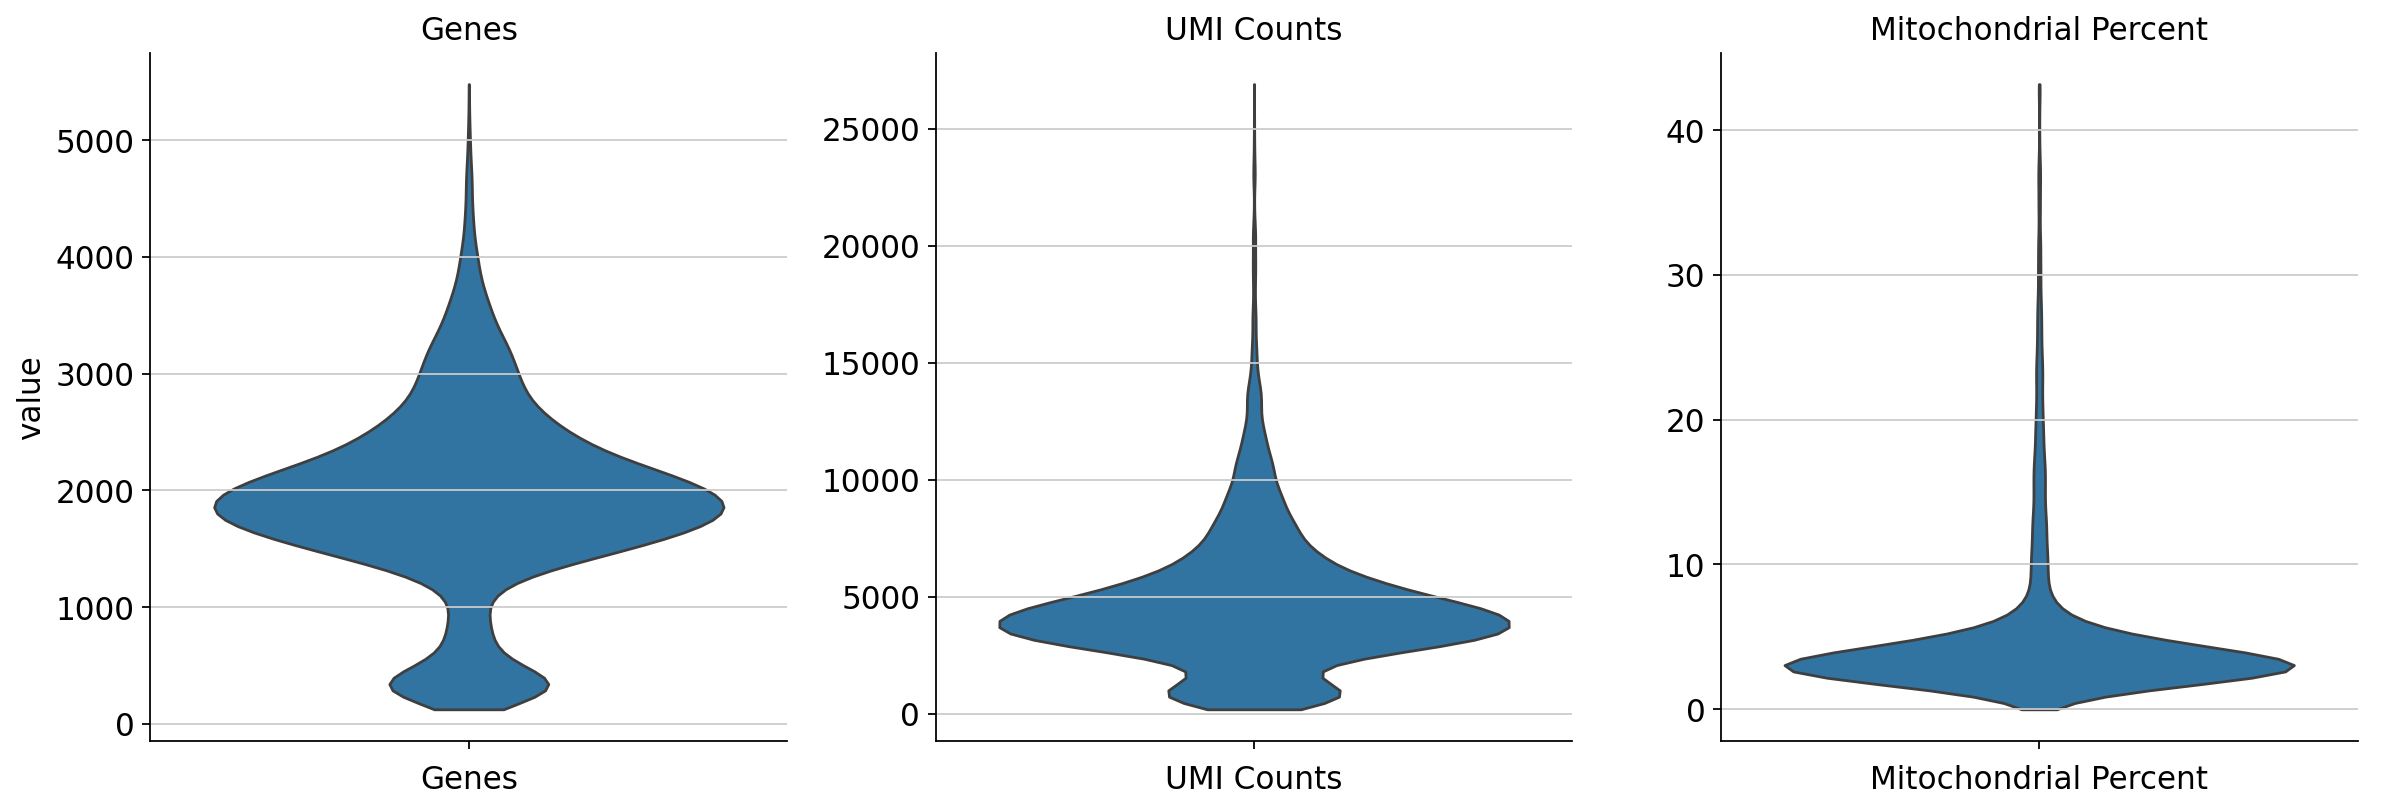


=== NK_CR ===


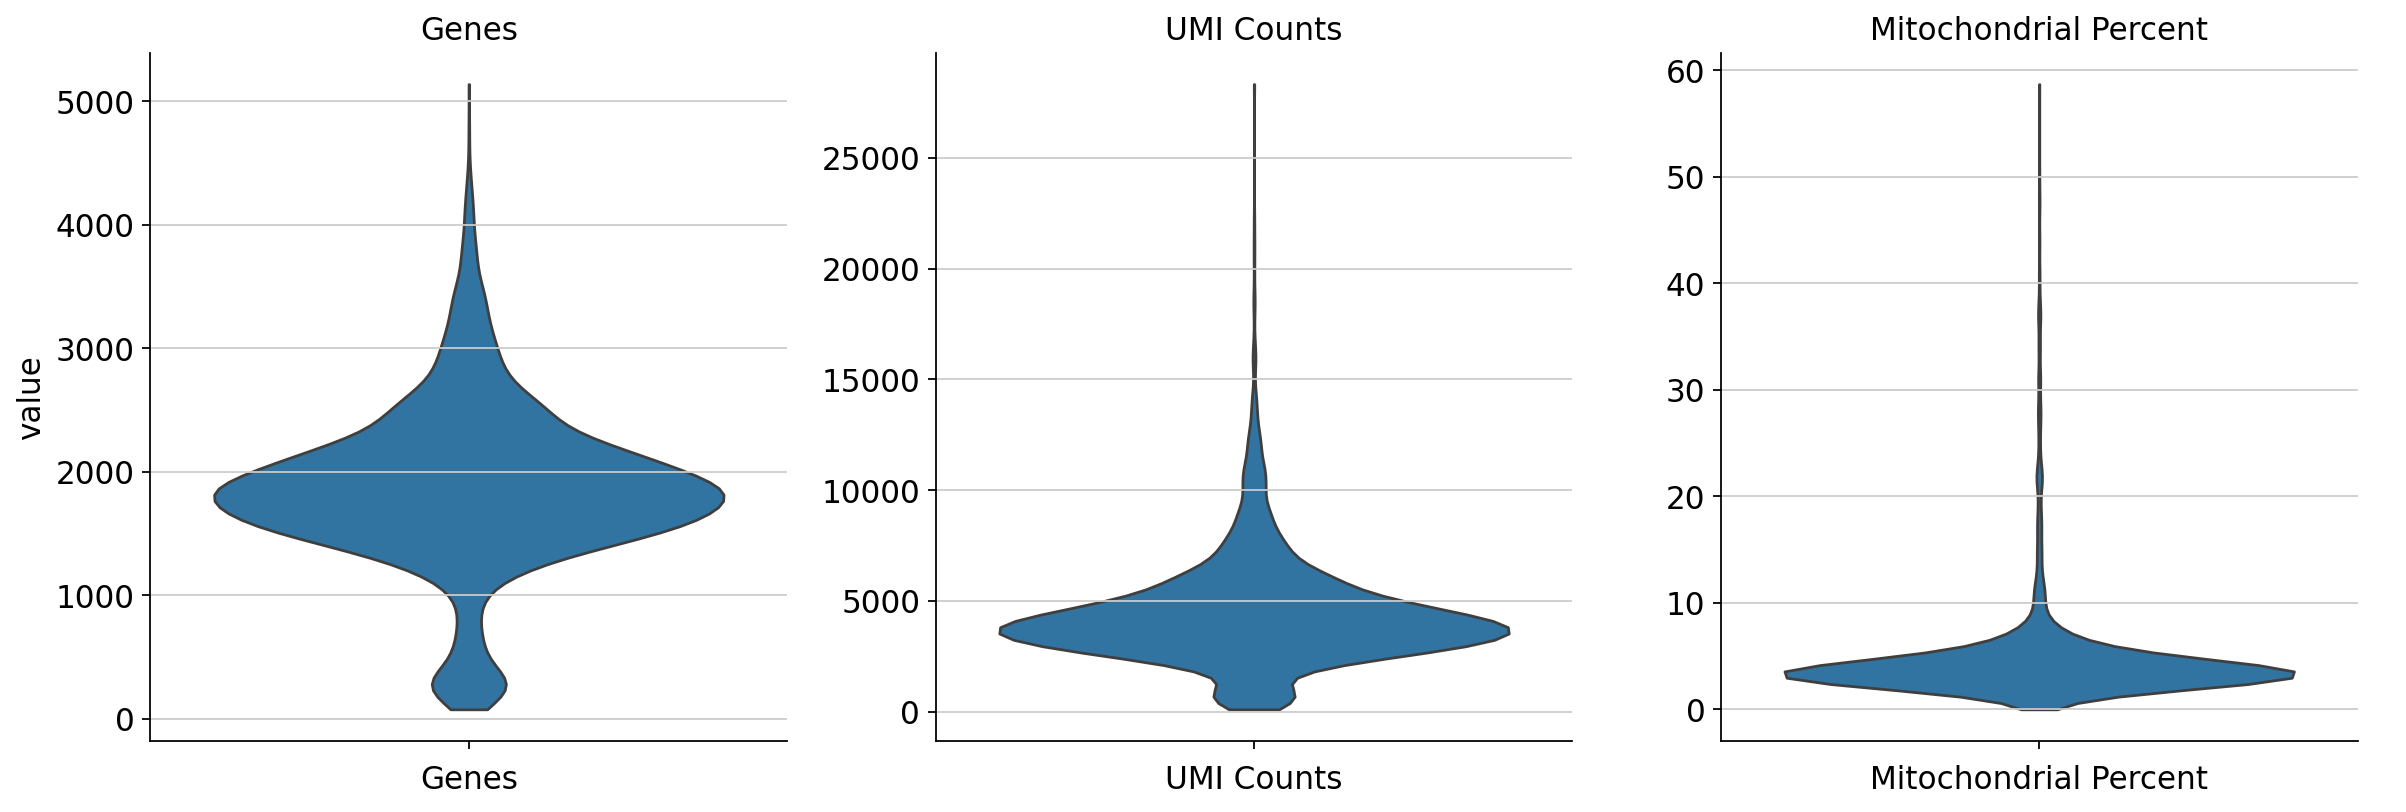

In [93]:
# Violin Plot Creation
samples_raw = {'NK_SFD': nk_sfd, 'NK_HFD': nk_hfd, 'NK_GLP': nk_glp, 'NK_CR': nk_cr}
samples_gex = {}
for name, adata in samples_raw.items():
    gex = adata[:, adata.var['feature_types'] == 'Gene Expression'].copy()
    gex.var_names_make_unique()
    samples_gex[name] = gex
    print(f"\n=== {name} ===")
    qc(gex)


=== NK_SFD ===


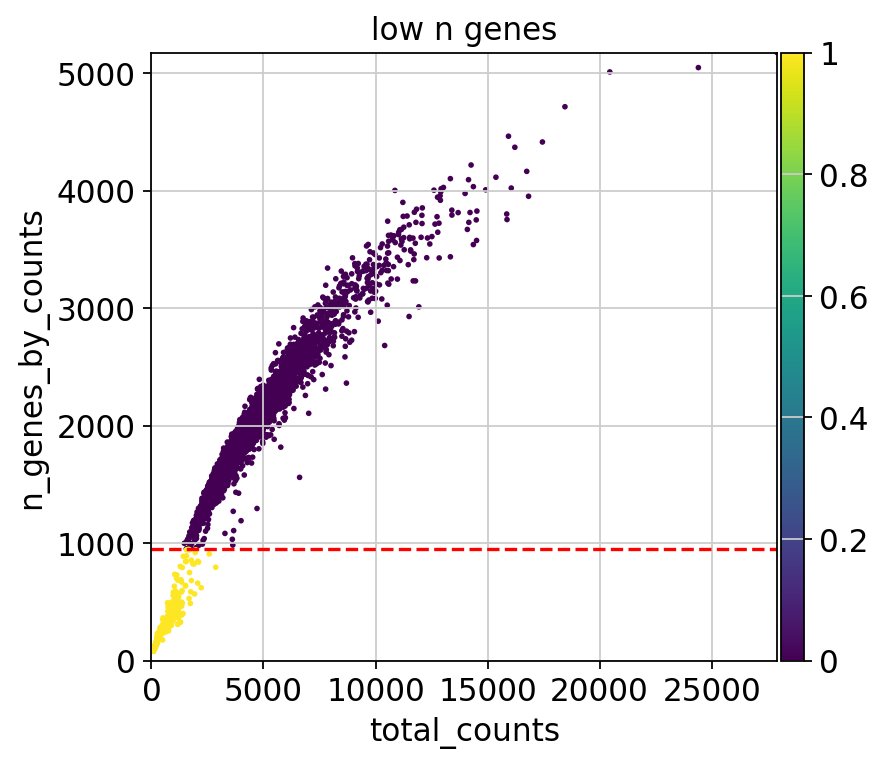

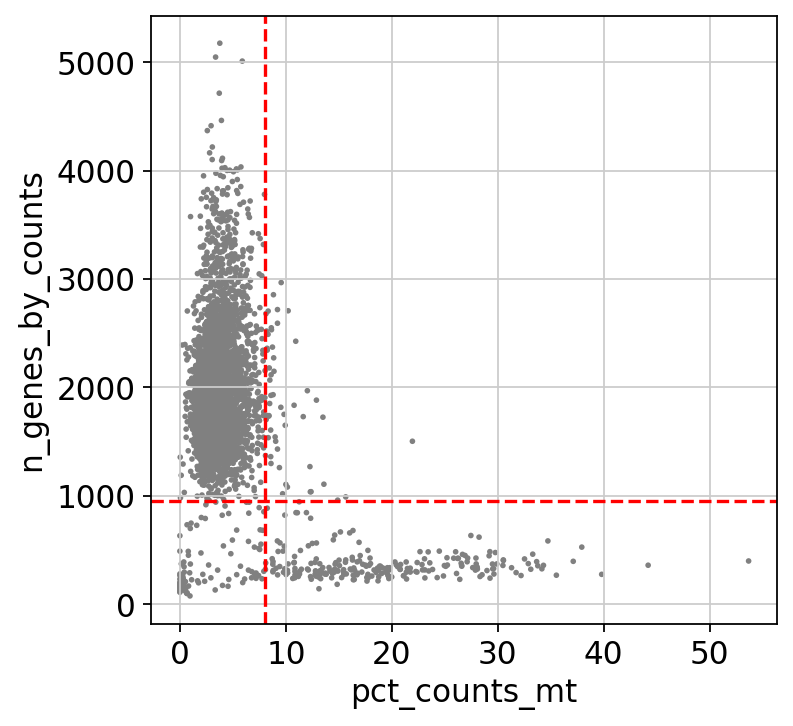


=== NK_HFD ===


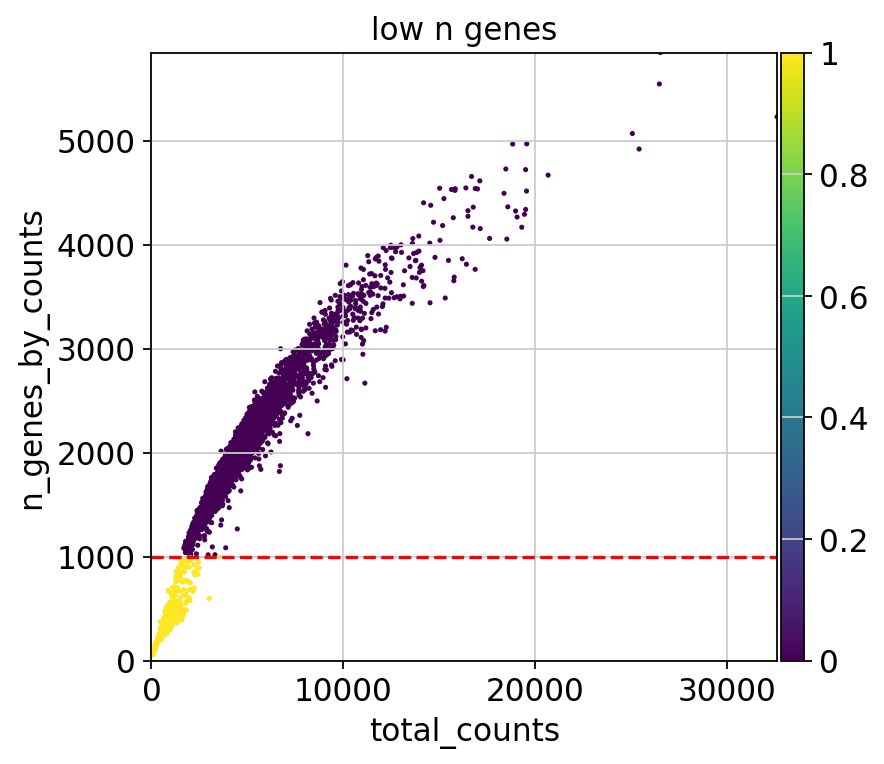

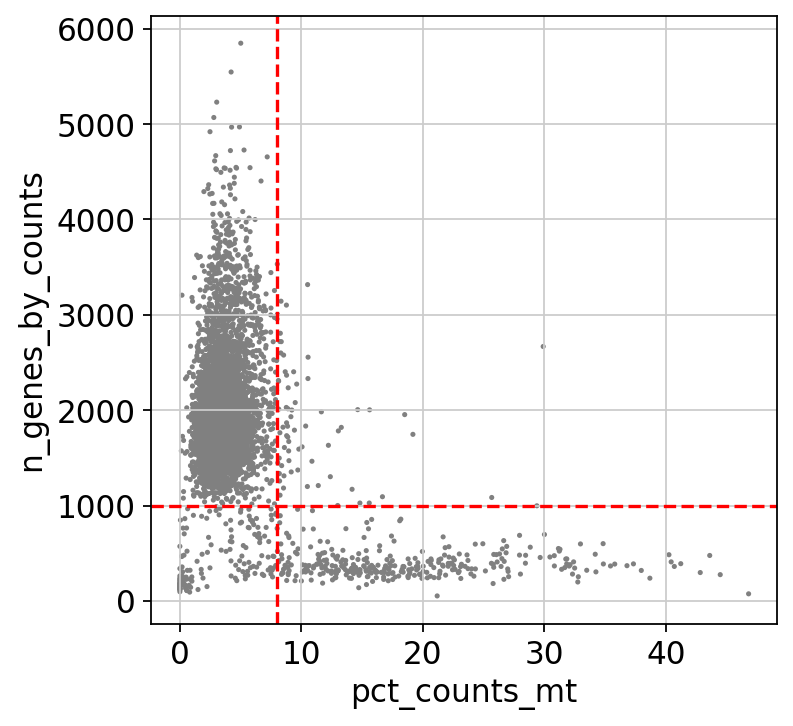


=== NK_GLP ===


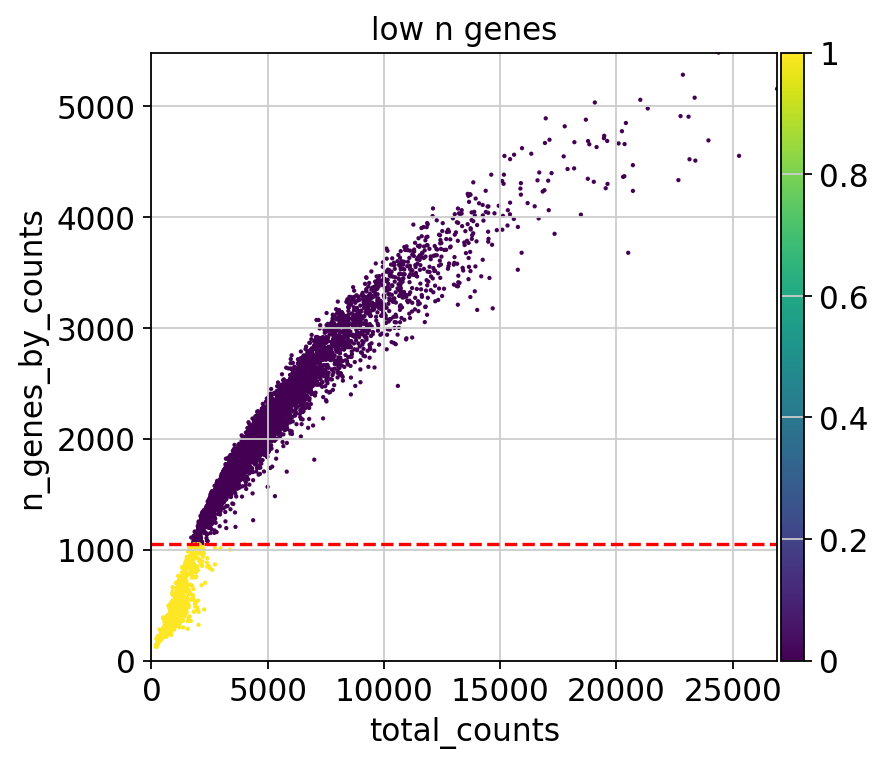

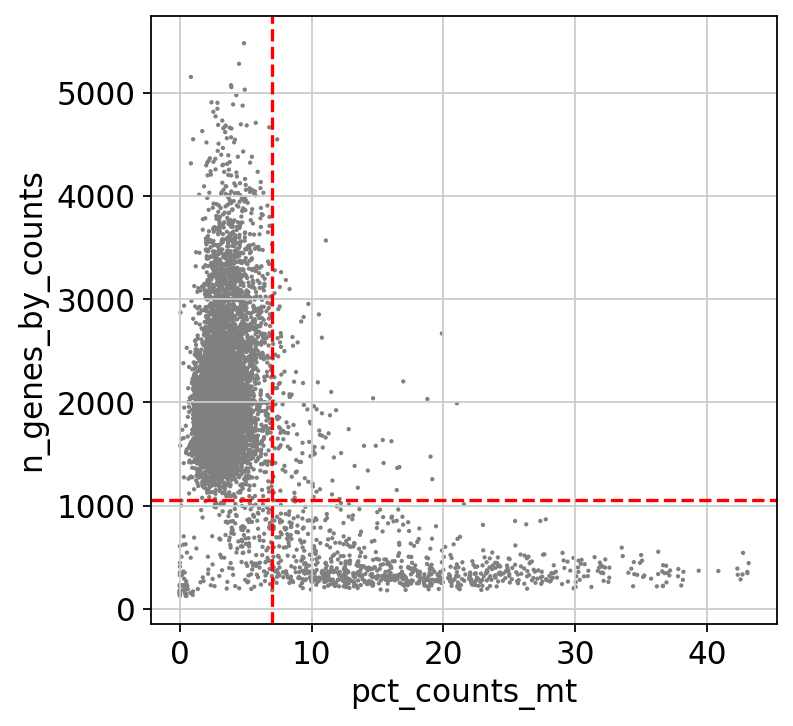


=== NK_CR ===


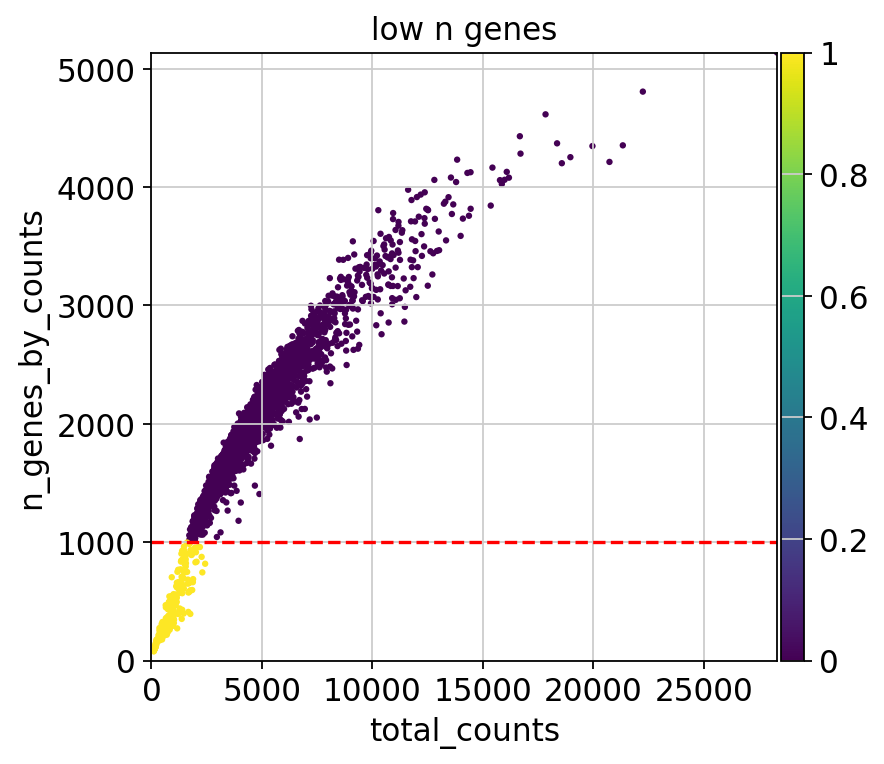

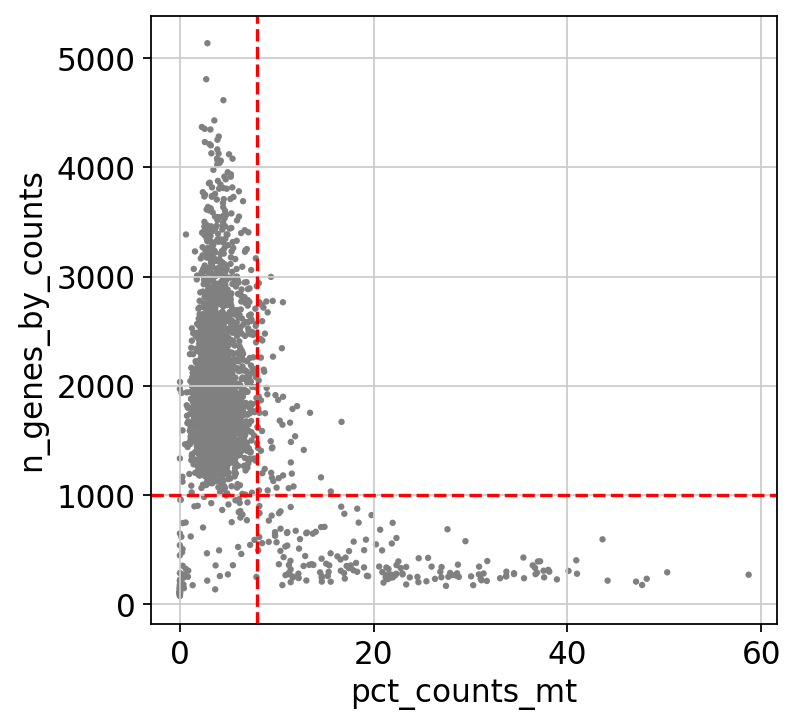

In [94]:
# Threshold Determination for 
thresholds = {
    'NK_SFD': dict(low_n_genes_thres=950, high_mt_thres=8),
    'NK_HFD': dict(low_n_genes_thres=1000, high_mt_thres=8),
    'NK_GLP': dict(low_n_genes_thres=1050, high_mt_thres=7),
    'NK_CR':  dict(low_n_genes_thres=1000, high_mt_thres=8),
}

for name, gex in samples_gex.items():
    print(f"\n=== {name} ===")
    qc2(gex, **thresholds[name])

In [95]:
samples_gex_filtered = {}
for name, gex in samples_gex.items():
    print(f"\n=== {name} ===")
    samples_gex_filtered[name] = qc_filter_cells(gex)


=== NK_SFD ===
Prior
(4641, 32285)
Post Cells with Low n Gene Filtering
(4303, 32285)
Post Cells with High MT Fraction Gene Filtering
(4247, 32285)

=== NK_HFD ===
Prior
(5637, 32285)
Post Cells with Low n Gene Filtering
(5157, 32285)
Post Cells with High MT Fraction Gene Filtering
(5089, 32285)

=== NK_GLP ===
Prior
(8031, 32285)
Post Cells with Low n Gene Filtering
(7018, 32285)
Post Cells with High MT Fraction Gene Filtering
(6871, 32285)

=== NK_CR ===
Prior
(3625, 32285)
Post Cells with Low n Gene Filtering
(3364, 32285)
Post Cells with High MT Fraction Gene Filtering
(3301, 32285)



=== NK_SFD ===


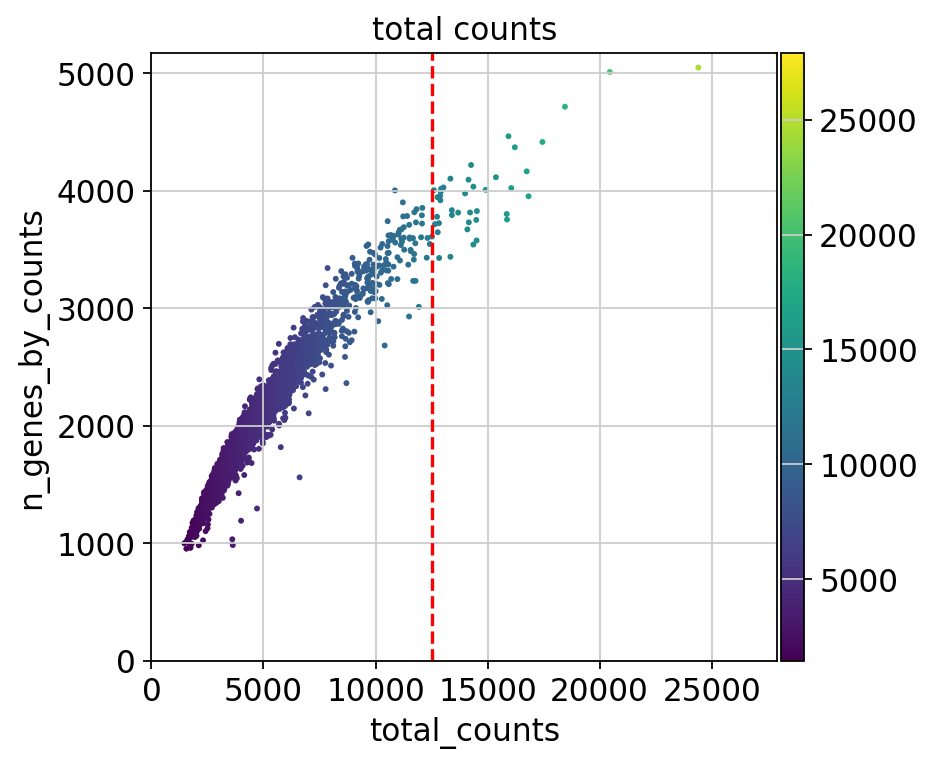

<ggplot: (640 x 480)>

=== NK_HFD ===


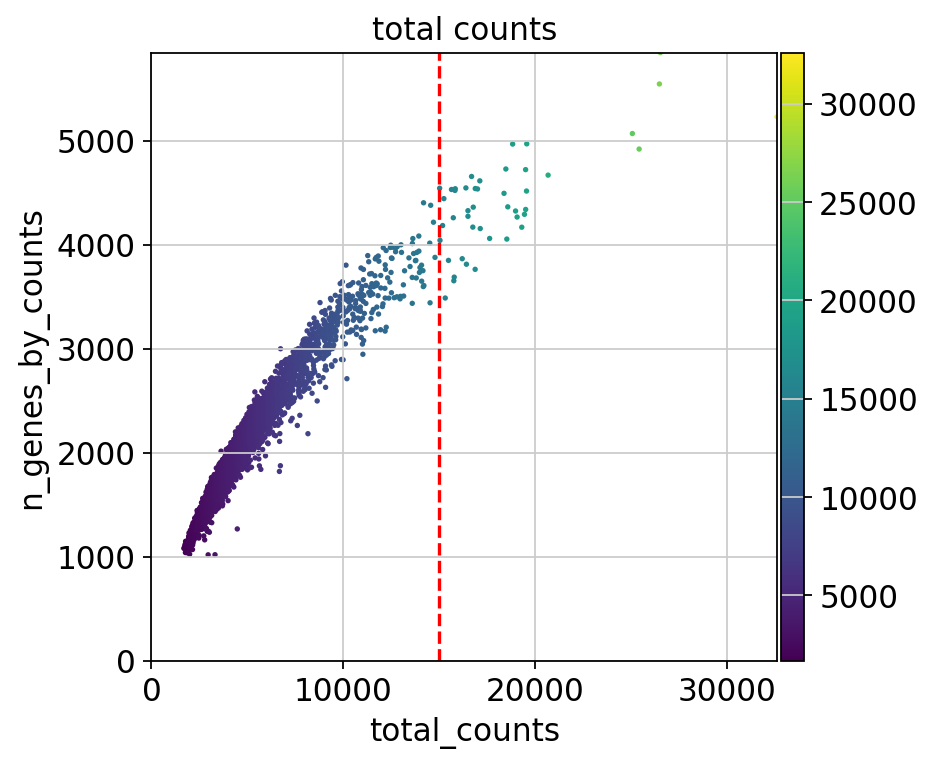

<ggplot: (640 x 480)>

=== NK_GLP ===


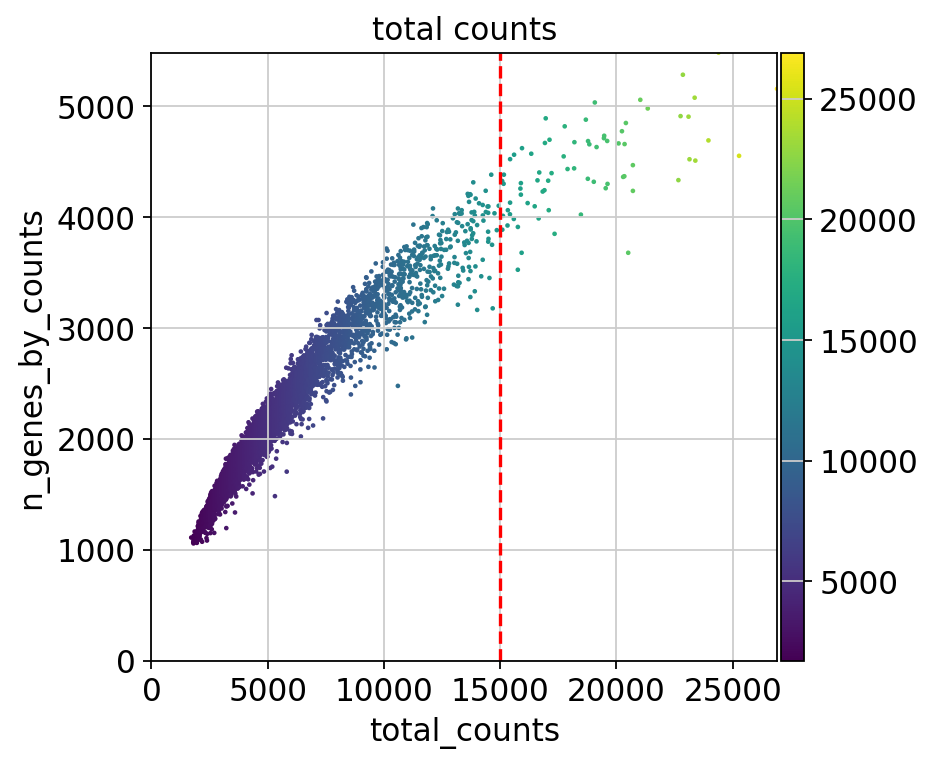

<ggplot: (640 x 480)>

=== NK_CR ===


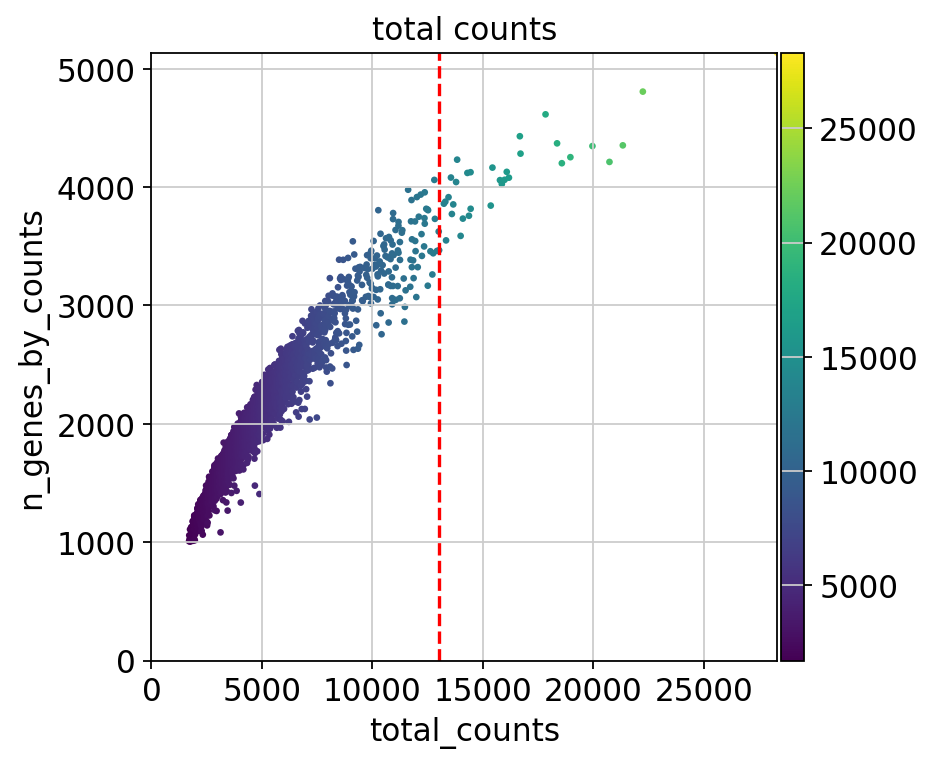

<ggplot: (640 x 480)>


In [96]:
thresholds_ct = {
    'NK_SFD': 12500,
    'NK_HFD': 15000,
    'NK_GLP': 15000,
    'NK_CR':  13000,
}

for name, gex in samples_gex_filtered.items():
    print(f"\n=== {name} ===")
    qc3(gex, high_ct_thres=thresholds_ct[name])

In [97]:
samples_gex_filtered2 = {}
for name, gex in samples_gex_filtered.items():
    print(f"\n=== {name} ===")
    samples_gex_filtered2[name] = qc_filter_cells2(gex)


=== NK_SFD ===
prior
(4247, 32285)
after filtering out high counts
(4204, 32285)

=== NK_HFD ===
prior
(5089, 32285)
after filtering out high counts
(5044, 32285)

=== NK_GLP ===
prior
(6871, 32285)
after filtering out high counts
(6797, 32285)

=== NK_CR ===
prior
(3301, 32285)
after filtering out high counts
(3266, 32285)



=== NK_SFD ===


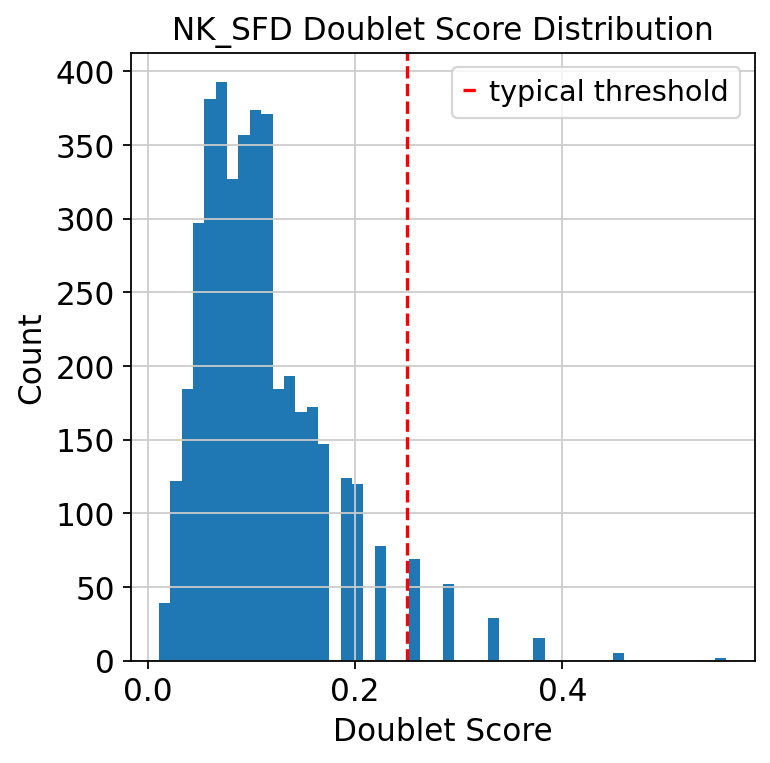


=== NK_HFD ===


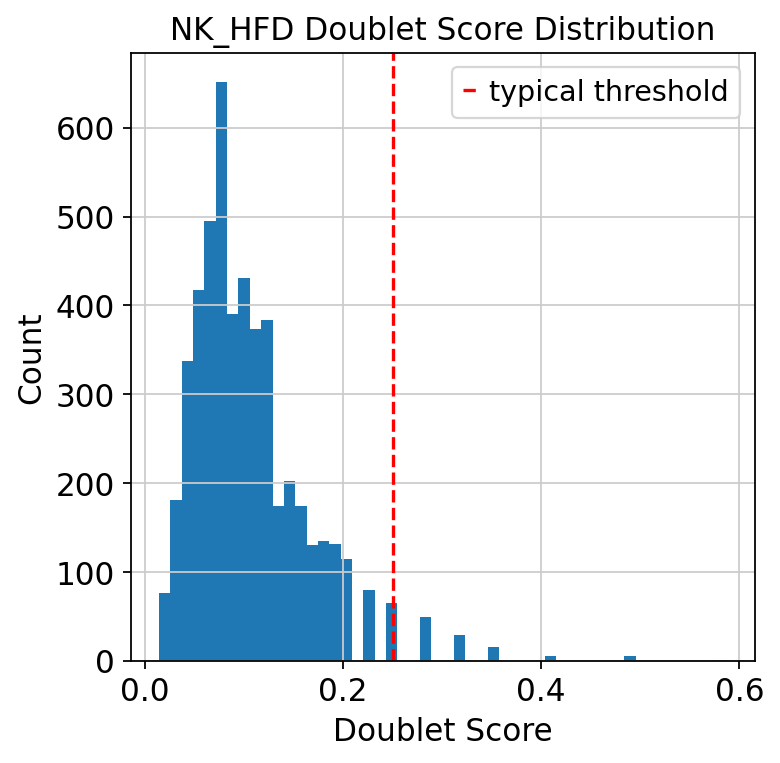


=== NK_GLP ===


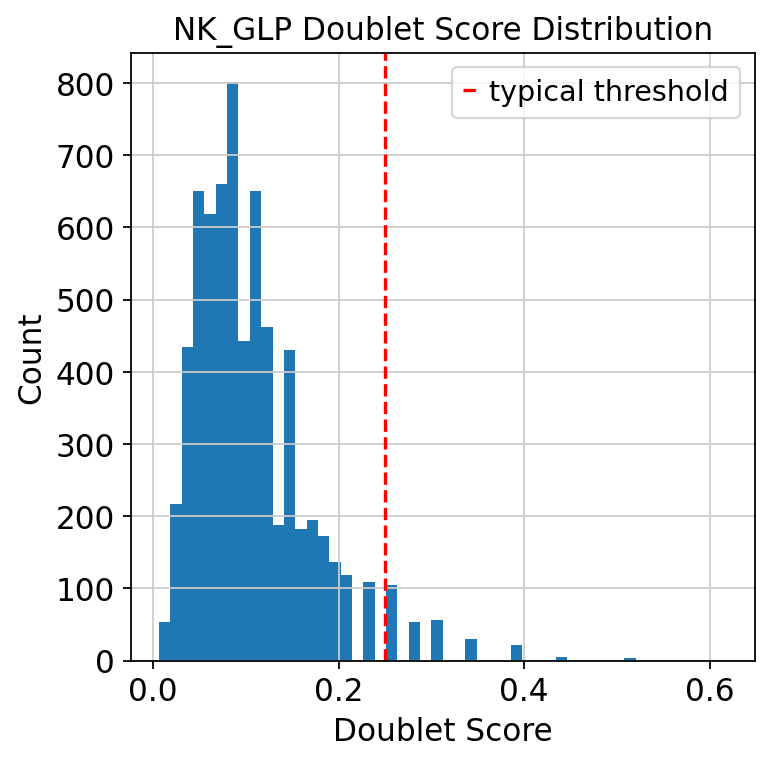


=== NK_CR ===


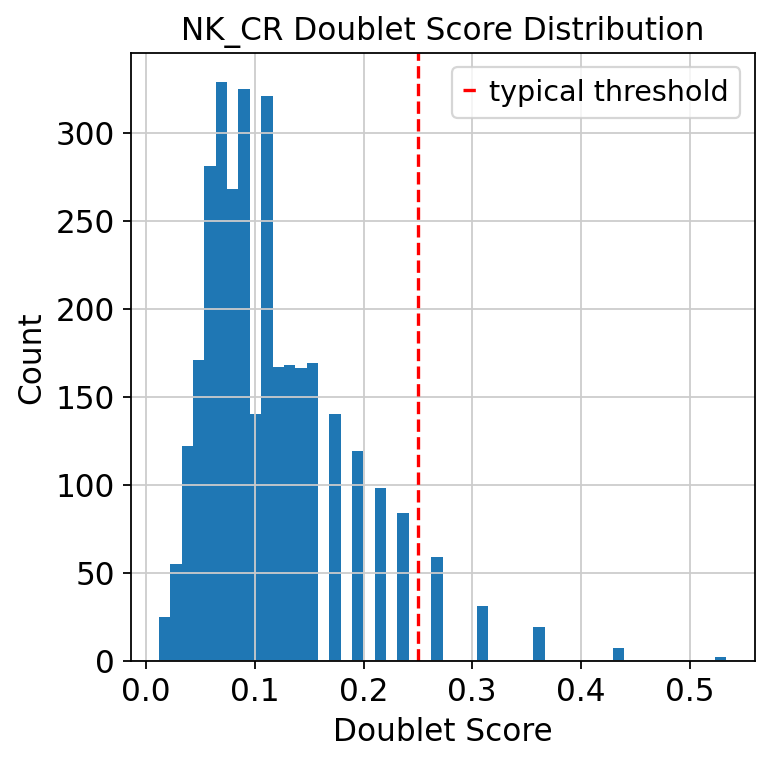

In [100]:
for name, gex in samples_gex_filtered2.items():
    print(f"\n=== {name} ===")
    sc.pp.scrublet(gex, batch_key=None)
    plt.hist(gex.obs['doublet_score'], bins=50)
    plt.axvline(0.0, c='r', linestyle='--', label='typical threshold')
    plt.xlabel('Doublet Score')
    plt.ylabel('Count')
    plt.title(f'{name} Doublet Score Distribution')
    plt.legend()
    plt.show()

In [103]:
doublet_thresholds = {
    'NK_SFD': 0.20,
    'NK_HFD': 0.20,
    'NK_GLP': 0.20,
    'NK_CR':  0.25,
}

samples_gex_final = {}
for name, gex in samples_gex_filtered2.items():
    print(f"\n=== {name} ===")
    samples_gex_final[name] = remove_doublets(gex, doublet_score_thres=doublet_thresholds[name])


=== NK_SFD ===
Prior
(4204, 32285)
After doublet removal (threshold=0.2)
(3834, 32285)

=== NK_HFD ===
Prior
(5044, 32285)
After doublet removal (threshold=0.2)
(4681, 32285)

=== NK_GLP ===
Prior
(6797, 32285)
After doublet removal (threshold=0.2)
(6295, 32285)

=== NK_CR ===
Prior
(3266, 32285)
After doublet removal (threshold=0.25)
(3148, 32285)



=== NK_SFD ===


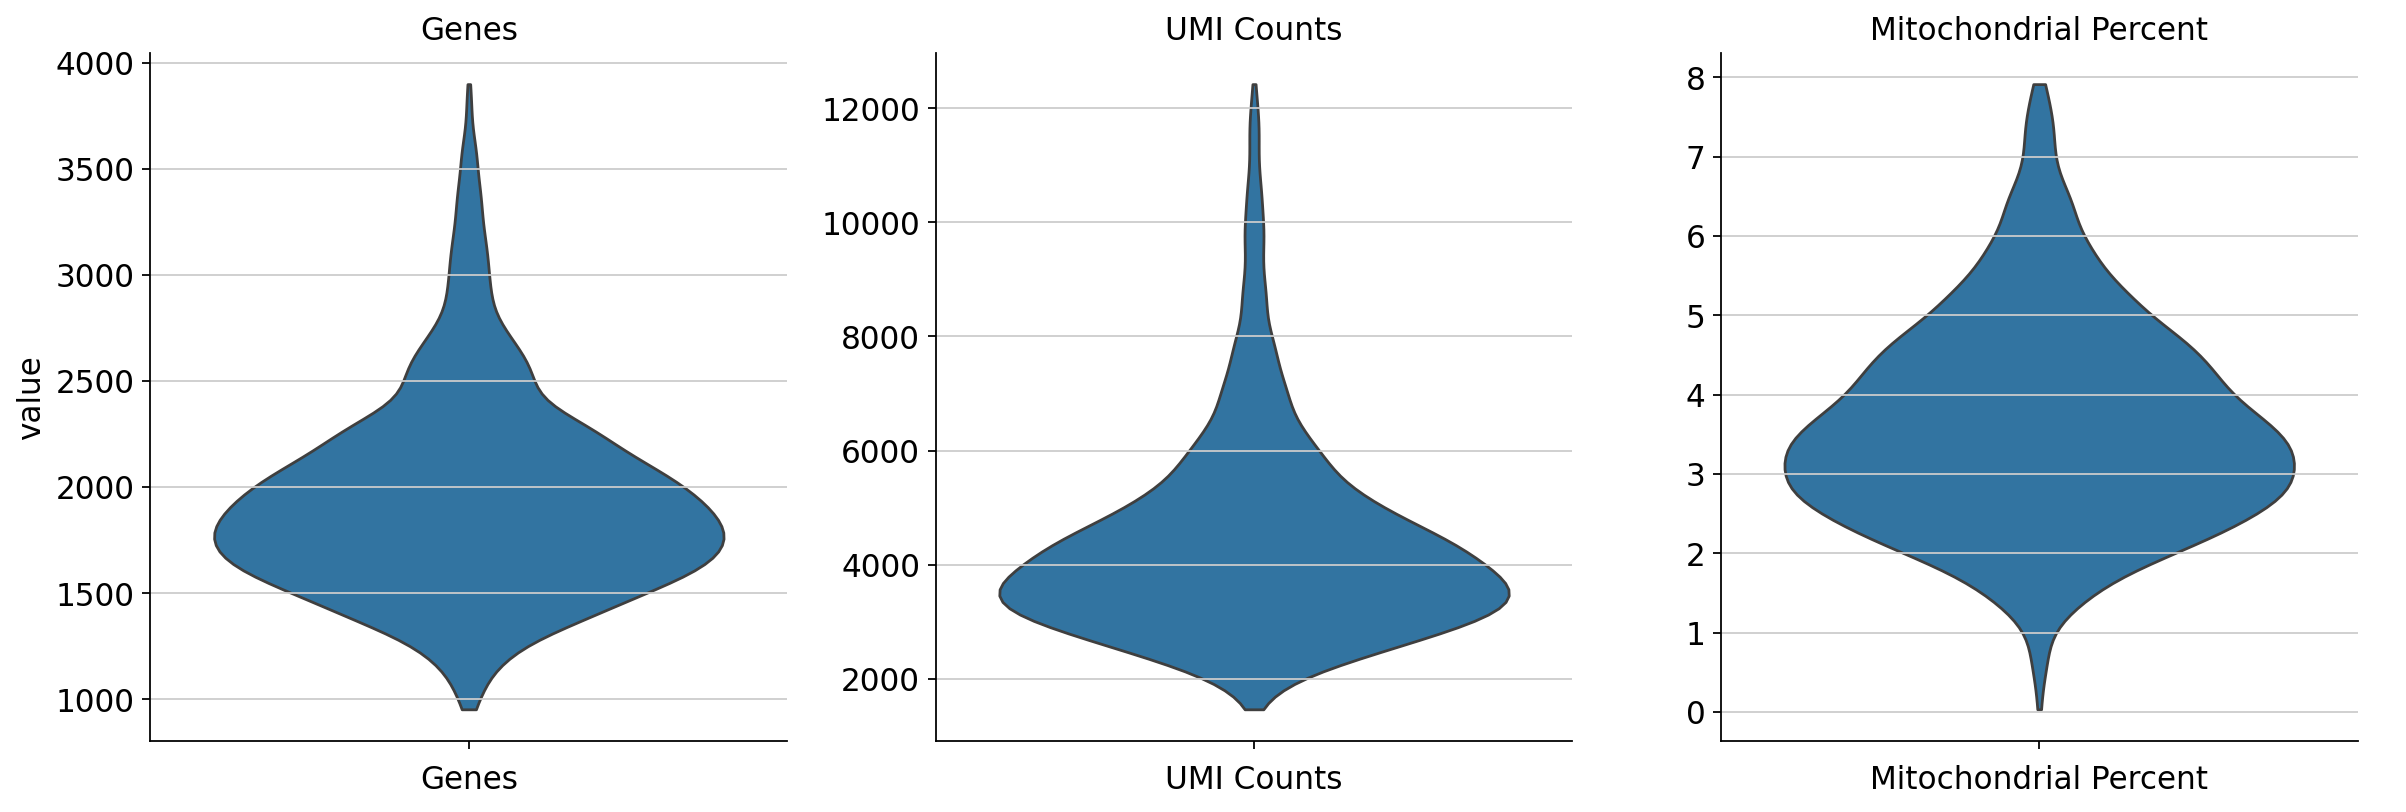


=== NK_HFD ===


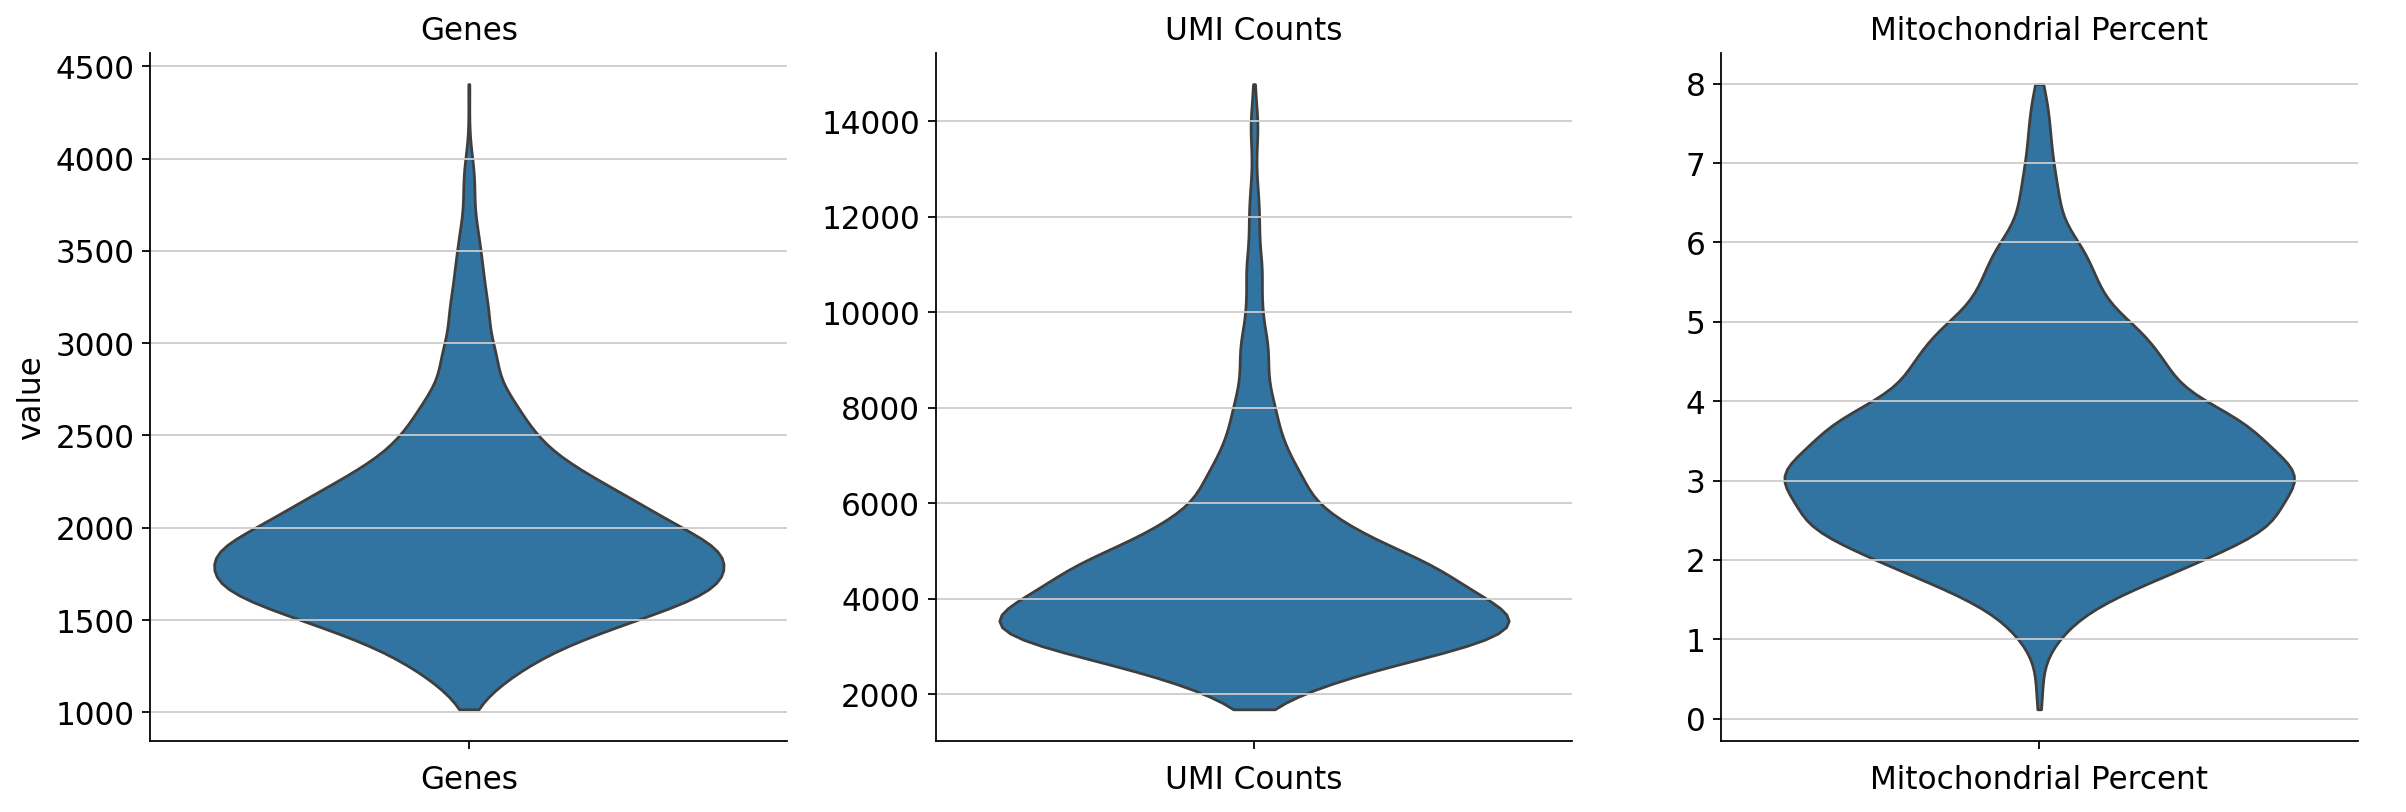


=== NK_GLP ===


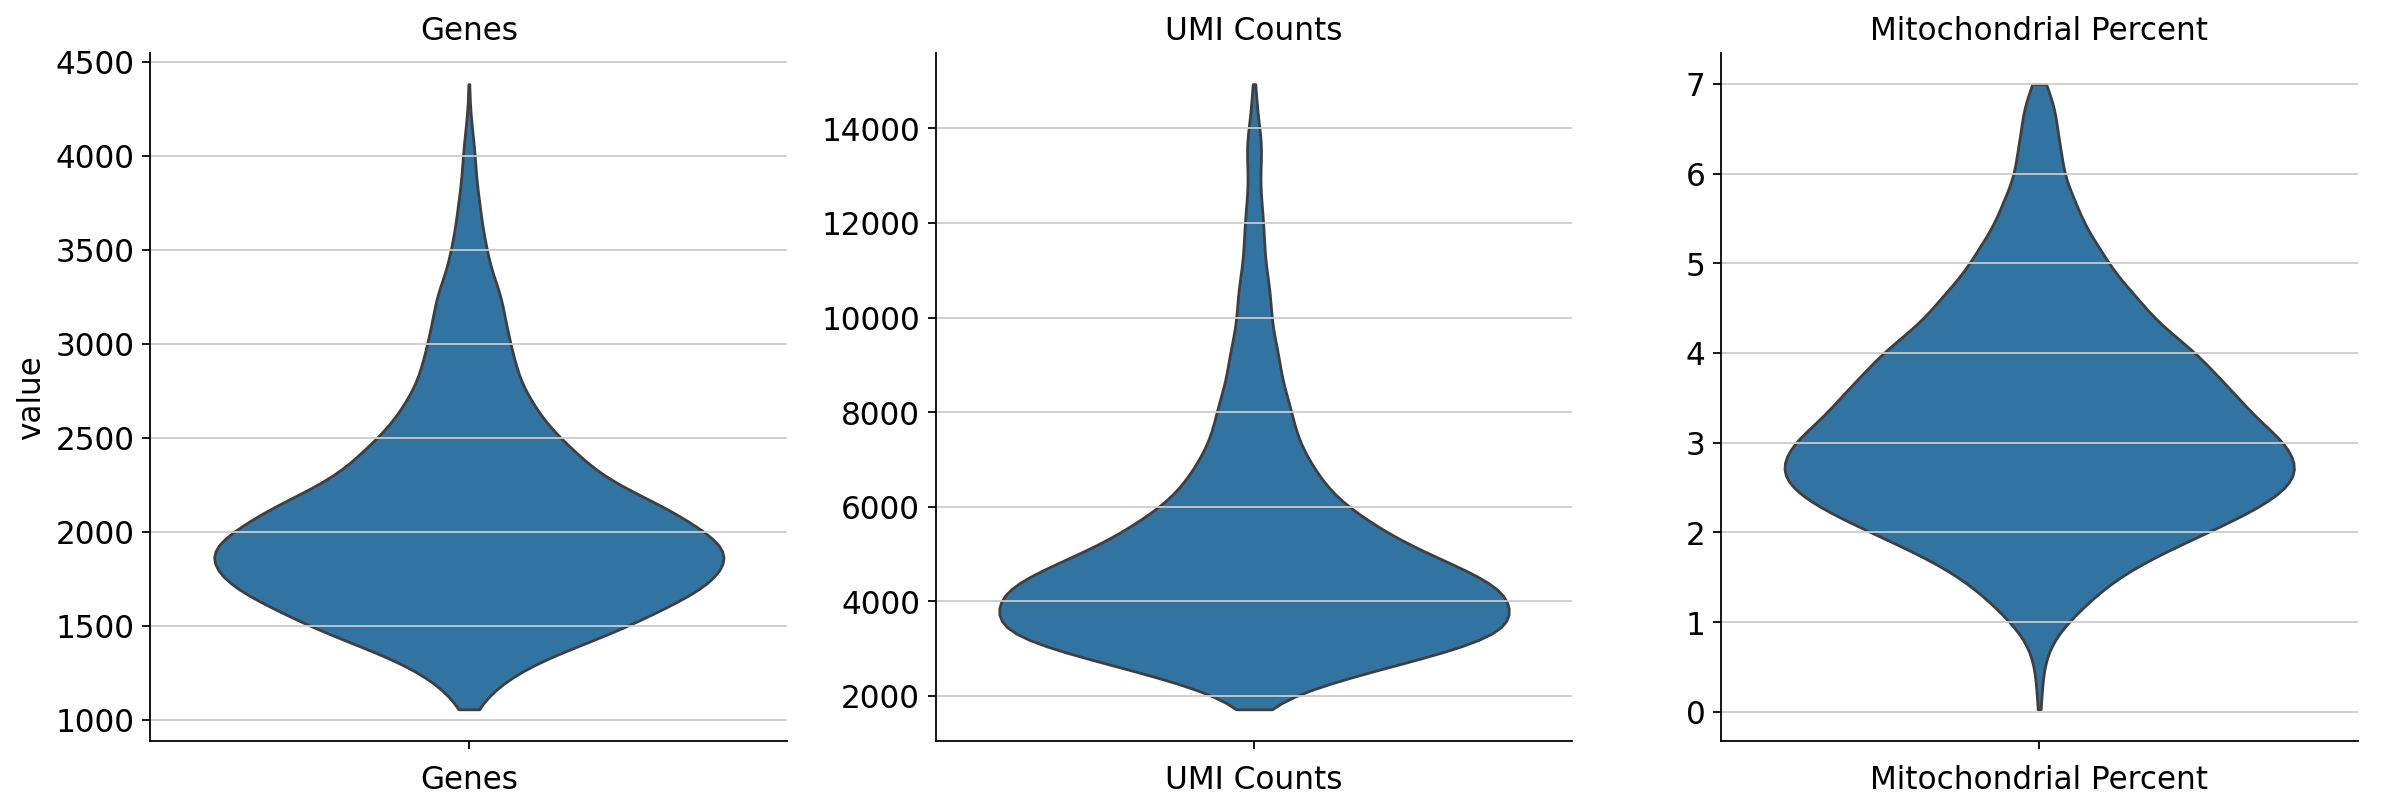


=== NK_CR ===


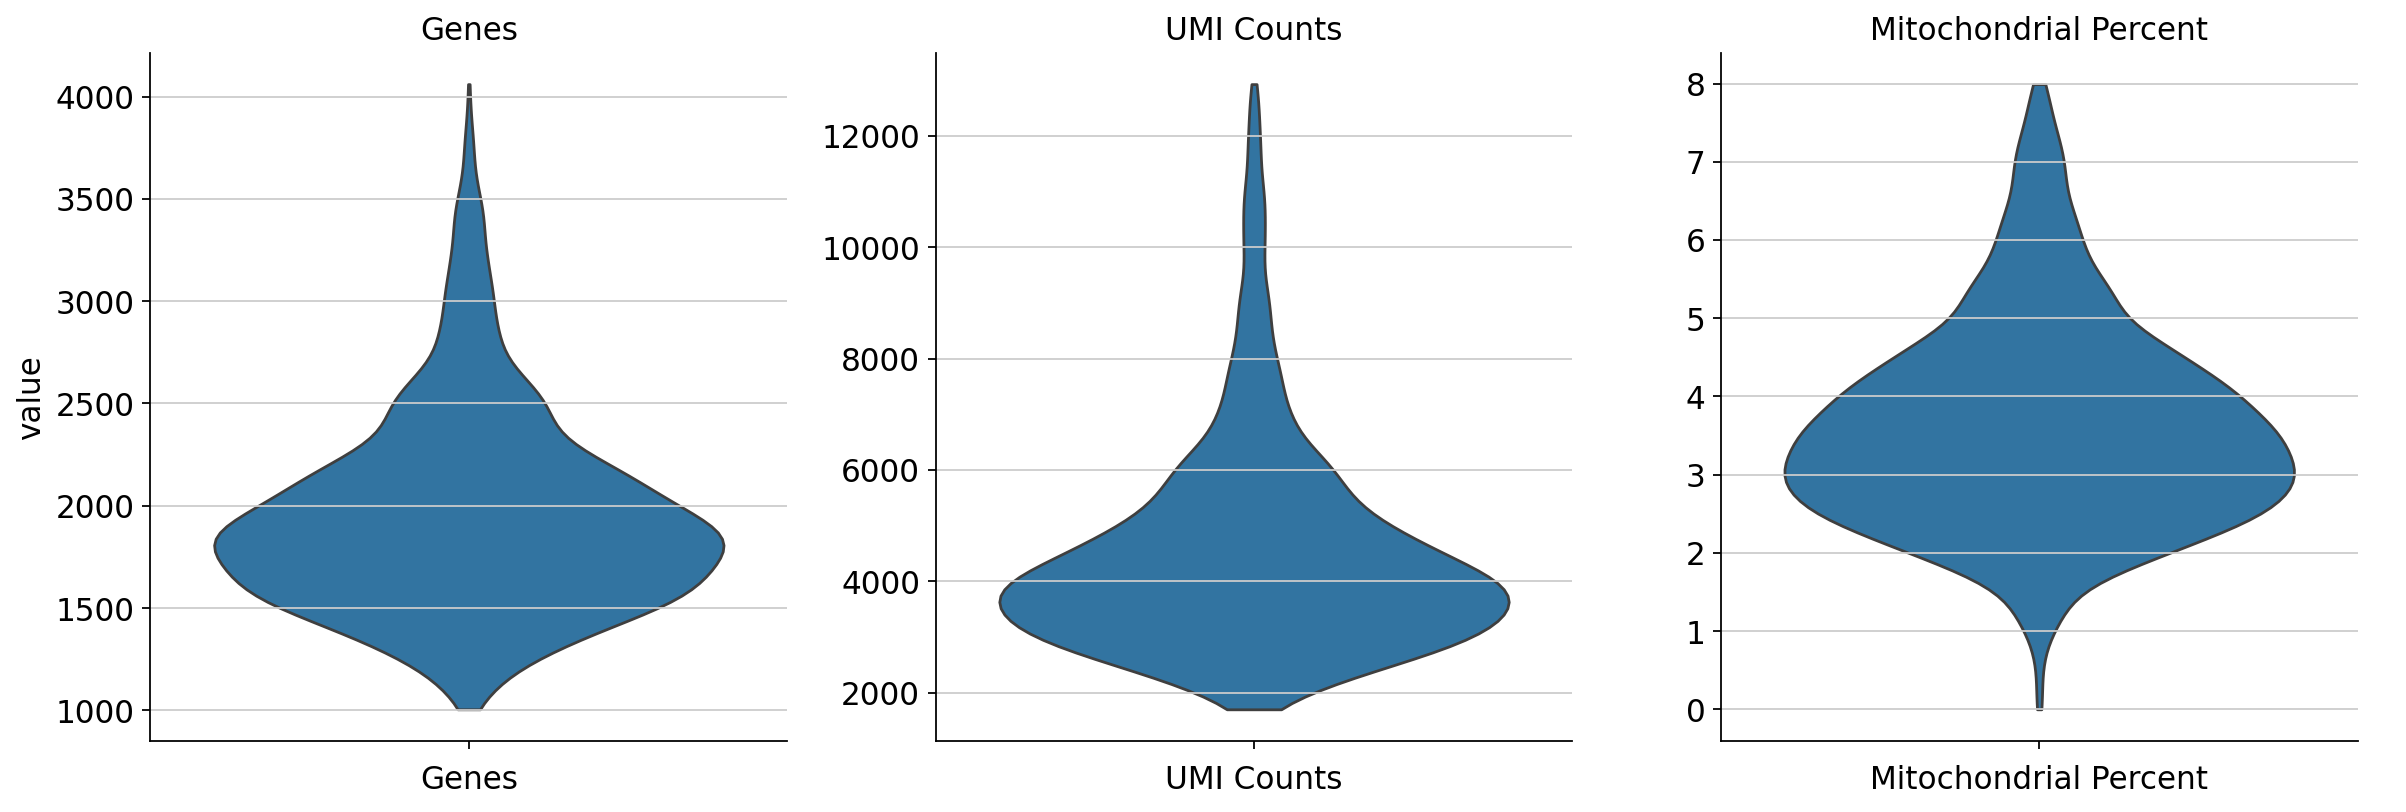

In [104]:
for name, gex in samples_gex_final.items():
    print(f"\n=== {name} ===")
    qc(gex)

In [ ]:
import os

out_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/'

for name, gex in samples_gex_final.items():
    out_path = os.path.join(out_dir, f'{name}_gex_filtered.h5ad')
    gex.write_h5ad(out_path)
    print(f"Saved {name} → {out_path}")